In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

Text(0.93, 0.5, 'Query length (number of conditions)')

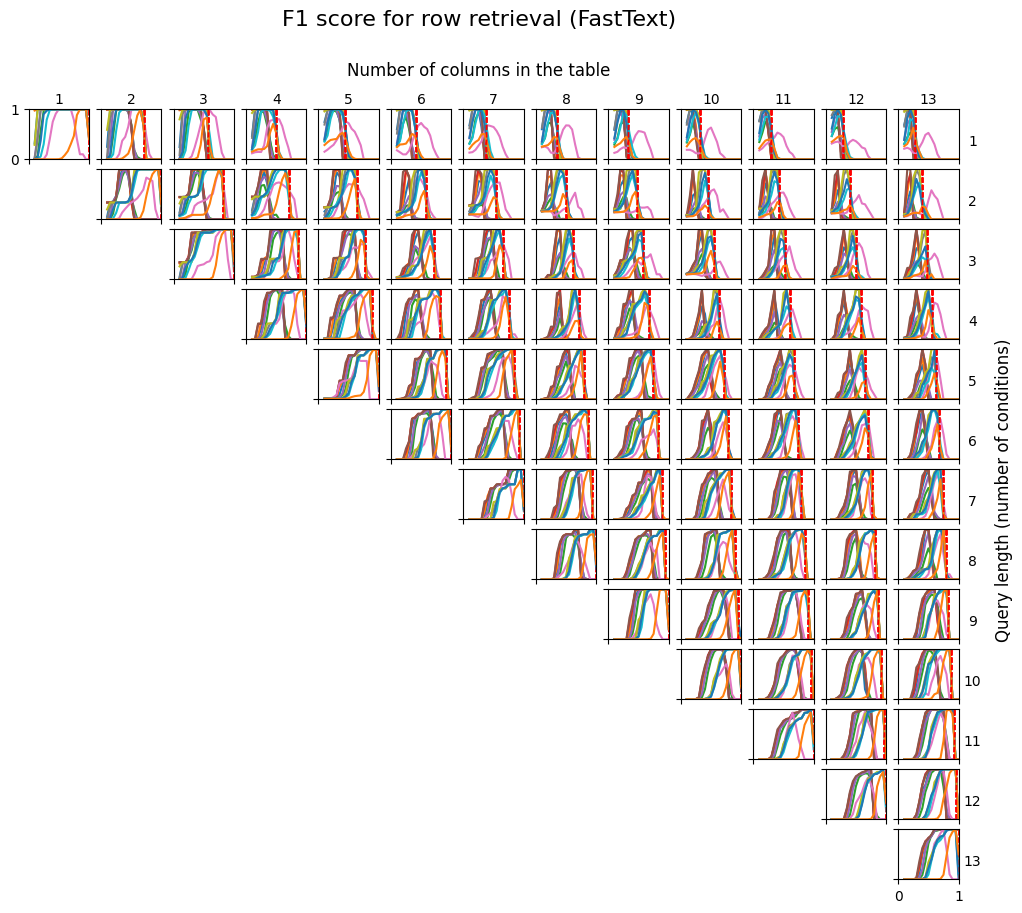

In [ ]:
df = pd.read_csv("../data/processed/threshold_selection_movie.csv")
df["f1"] = 2 * df["recall"] * df["precision"] / (df["recall"] + df["precision"])
df["f1"] = df["f1"].fillna(0)

df['t'] = df['t'].astype(float)
df['recall'] = df['recall'].astype(float)
df['precision'] = df['precision'].astype(float)
df['f1'] = df['f1'].astype(float)

agg_df = (
    df.groupby(['model', 'n', 'm', 't'], as_index=False)
      .agg({'recall': 'mean', 'precision': 'mean', 'f1': 'mean'})
)

MARGIN = 0.0
LIMITS = {'x': (0-MARGIN, 1+MARGIN), 'y': (0-MARGIN, 1+MARGIN)}

q_lengths = agg_df['n'].unique()
c_nums = agg_df['m'].unique()
q_lengths.sort()
c_nums.sort()

fig, axes = plt.subplots(
    nrows=len(q_lengths),
    ncols=len(c_nums),
    figsize=(12, 10),
    sharex=True, 
    sharey=True
)
for i, q_len in enumerate(q_lengths):
    for j, c_num in enumerate(c_nums):
        fdf = agg_df[(agg_df["n"] == q_len) & (agg_df['m'] == c_num)]
        subset = fdf.groupby('model')

        ax = axes[i, j]
        if j < i:
            ax.set_visible(False)
        else:
            for model, model_group in fdf.groupby('model'):
                ax.plot(model_group['t'], model_group['f1'], label=f'{model}')

                tau = (q_len / c_num) ** 0.5
                ax.axvline(x=tau, color="red", linestyle="--", linewidth=1, label="positives")

            # ax.set_title("Recall vs Threshold")
            # ax.set_xlabel("Threshold")
            # ax.set_ylabel("Recall")
            ax.set_xlim(*LIMITS['x'])
            ax.set_ylim(*LIMITS['y'])
            # ax.grid(True, linestyle='--', alpha=0.6)

for j, c_num in enumerate(c_nums):
    axes[0, j].xaxis.set_label_position("top")
    axes[0, j].set_xlabel(f"{c_num}")
for i, q_len in enumerate(q_lengths):
    axes[i, -1].yaxis.set_label_position("right")
    axes[i, -1].set_ylabel(f"{q_len}", rotation=0, labelpad=10)

fig.suptitle("F1 Score for movie dataset", fontsize=16)
fig.supxlabel("Number of columns in the table", fontsize=12, y=0.91)
fig.supylabel("Query length (number of conditions)", fontsize=12, x=0.93)